
##########################################################################
david_bulkCuO.csv
--------------------------------------------------------------------------
Fermi_bulkXCH = 11.7891 eV
total_shift = D_E + d_exp
D_E = (E_bulkXCH - E_atomXCH) - (E_bulkGS - E_atomGS)
D_E = 1.1610819335390707 eV
E_bulkXCH = -182888.1213842135 eV
E_atomXCH = -651.8717703595056 eV
E_bulkGS = -182681.847761322 eV
E_atomGS = -444.43706553444804 eV

d_exp = 528.998918066461
bulkCuO total shift: 530.1600000000001

##########################################################################
david_Au_111_cuso4_sulfate.csv
--------------------------------------------------------------------------
Fermi_bulkXCH = 6.74315 eV
total_shift = D_E + d_exp
D_E = (E_bulkXCH - E_atomXCH) - (E_bulkGS - E_atomGS)
D_E = 2.3219356994966156 eV
E_bulkXCH = -295632.2456113274 eV
E_atomXCH = -652.318753246136 eV
E_bulkGS = -295427.30530756124 eV
E_atomGS = -445.0565137805008 eV

Au_111_cuso4_sulfate total_shift: 531.3208537

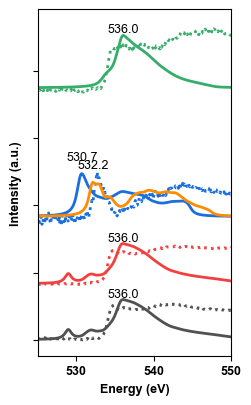

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import scipy.signal
import textwrap
from scipy.interpolate import interp1d
from matplotlib import font_manager

arial = font_manager.FontProperties(fname="/mnt/c/Windows/Fonts/arial.ttf", size=9)
arialbd = font_manager.FontProperties(fname="/mnt/c/Windows/Fonts/arialbd.ttf", size=9)
# Constants

yoffset=1/6
E_i = -15 #eV
E_f = 17 #eV
eV_Ry = 13.60570398 

def getShift(filename):
    raw_data = np.loadtxt(filename, delimiter=",", dtype=str)
    # Extract headers (second column onward)
    headers = raw_data[0, 1:]  # ['energy', 'fermi']
    # Create the nested dictionary
    d = {
        row[0]: {headers[i]: float(row[i + 1]) for i in range(len(headers))}
        for row in raw_data[1:]
    }
    
    D_E = (d["bulkXCH/scf.out"]["energy"]-d["atomXCH/scf.out"]["energy"])-(d["bulkGS/scf.out"]["energy"]-d["atomGS/scf.out"]["energy"])
    # Fermi is given in QE in eV while the rest of energies in Ry. We convert accordingly
    shift = D_E*eV_Ry
    text=textwrap.dedent(f'''
    ##########################################################################
    {filename}
    --------------------------------------------------------------------------
    Fermi_bulkXCH = {d["bulkXCH/scf.out"]["fermi"]} eV
    total_shift = D_E + d_exp
    D_E = (E_bulkXCH - E_atomXCH) - (E_bulkGS - E_atomGS)
    D_E = {D_E*eV_Ry} eV
    E_bulkXCH = {d["bulkXCH/scf.out"]["energy"]*eV_Ry} eV
    E_atomXCH = {d["atomXCH/scf.out"]["energy"]*eV_Ry} eV
    E_bulkGS = {d["bulkGS/scf.out"]["energy"]*eV_Ry} eV
    E_atomGS = {d["atomGS/scf.out"]["energy"]*eV_Ry} eV
    ''')
    print(text)
    return shift

def exp(filename):
    data = np.loadtxt(filename)
    energy = data[:, 0]
    intensity = data[:, 1]
    return energy, intensity

def raw(filename):
    data = np.loadtxt(filename)
    energy = data[:, 0]
    frames = len(data[0,:])-1
    intensity = np.sum(data[:, 1:], axis=1) / frames
    return energy, intensity

def norm_area(filename):
    data = np.loadtxt(filename)
    energy = data[:, 0]
    frames = len(data[0,:])-1
    intensity = np.sum(data[:, 1:], axis=1) / frames
    mask = (energy >= E_i) & (energy <= E_f)
    energy_range = energy[mask]
    intensity_range = intensity[mask]
    auc = simpson(intensity_range, energy_range)
    intensity = intensity / auc
    return energy, intensity

def givePeak(energy, intensity, name):
    # Find peaks
    peaks, _ = scipy.signal.find_peaks(intensity, prominence=0.1)

    # Get the first peak energy
    if peaks.size > 0:
        first_peak_energy = energy[peaks[0]]
        first_peak_intensity = intensity[peaks[0]]
        #print(f"{name} peak: {first_peak_energy:.4f} eV")
    else:
        peaks, _ = scipy.signal.find_peaks(intensity)
        if peaks.size > 0:
            first_peak_energy = energy[peaks[0]]
            first_peak_intensity = intensity[peaks[0]]
            print("WARNING: Very small peaks.")
        else:
            print("No peaks where found")
    return first_peak_energy, first_peak_intensity

# Experimental reference data
energy_bulkCuO_exp, intensity_bulkCuO_exp = exp("exp_bulkCuO.dat")
# Reverse the order of this data
energy_bulkCuO_exp = energy_bulkCuO_exp[::-1]
intensity_bulkCuO_exp = intensity_bulkCuO_exp[::-1]
x_bulkCuO_exp,y_bulkCuO_exp  = givePeak(energy=energy_bulkCuO_exp, intensity=intensity_bulkCuO_exp, name='bulkCuO')
# COmputational reference
energy_bulkCuO, intensity_bulkCuO = norm_area("polAvg_bulkCuO.dat")
x_bulkCuO,y_bulkCuO  = givePeak(energy=energy_bulkCuO, intensity=intensity_bulkCuO, name='bulkCuO')
shift_bulkCuO = getShift('david_bulkCuO.csv')
# ------------------------------------------------------------------------------------------------------------
# Experimental shift
d_exp = x_bulkCuO_exp - (x_bulkCuO+shift_bulkCuO)
print(f'd_exp = {d_exp}')
# ------------------------------------------------------------------------------------------------------------
print('bulkCuO total shift: ' + str(shift_bulkCuO + d_exp))
energy_bulkCuO += shift_bulkCuO + d_exp
x_bulkCuO,y_bulkCuO  = givePeak(energy=energy_bulkCuO, intensity=intensity_bulkCuO, name='bulkCuO')


# Experimental data

energy_0V_exp, intensity_0V_exp = exp("exp_0V.dat")
x_0V_exp, y_0V_exp = givePeak(energy=energy_0V_exp, intensity=intensity_0V_exp, name='0V')

energy_minus01V_exp, intensity_minus01V_exp = exp("exp_-0.1V.dat")
x_minus01V_exp,y_minus01V_exp  = givePeak(energy=energy_minus01V_exp, intensity=intensity_minus01V_exp, name='minus01V')

energy_minus02V_exp, intensity_minus02V_exp = exp("exp_-0.2V.dat")
#peaks_minus02V_exp, _ = scipy.signal.find_peaks(intensity_minus02V_exp, prominence=0.15)
#x_minus02V_exp = energy_minus02V_exp[peaks_minus02V_exp[0]]
#y_minus02V_exp = intensity_minus02V_exp[peaks_minus02V_exp[0]]
x_minus02V_exp, y_minus02V_exp = givePeak(energy=energy_minus02V_exp, intensity=intensity_minus02V_exp, name='minus02V')

energy_minus03V_exp, intensity_minus03V_exp = exp("exp_-0.3V.dat")
x_minus03V_exp, y_minus03V_exp = givePeak(energy=energy_minus03V_exp, intensity=intensity_minus03V_exp, name='minus03V')


# Process data

#energy_cuso4_solv_sulfate, intensity_cuso4_solv_sulfate = norm_area("polAvg_cuso4_solv_sulfate.dat")
#shift_cuso4_solv_sulfate = getShift('david_cuso4_solv_sulfate.csv')
#print('cuso4_solv_sulfate total_shift: ' + str(shift_cuso4_solv_sulfate + d_exp))
#energy_cuso4_solv_sulfate += shift_cuso4_solv_sulfate+ d_exp
#x_cuso4_solv_sulfate,y_cuso4_solv_sulfate  = givePeak(energy=energy_cuso4_solv_sulfate, intensity=intensity_cuso4_solv_sulfate, name='cuso4_solv_sulfate')


#energy_Au_111_watbox, intensity_Au_111_watbox = norm_area("polAvg_Au_111_watbox.dat")
#shift_Au_111_watbox = getShift('david_Au_111_watbox.csv')
#print('Au_111_watbox total_shift: ' + str(shift_Au_111_watbox + d_exp))
#energy_Au_111_watbox += shift_Au_111_watbox+ d_exp
#x_Au_111_watbox,y_Au_111_watbox  = givePeak(energy=energy_Au_111_watbox, intensity=intensity_Au_111_watbox, name='Au_111_watbox')

energy_Au_111_cuso4_sulfate, intensity_Au_111_cuso4_sulfate = norm_area("polAvg_Au_111_cuso4_sulfate.dat")
shift_Au_111_cuso4_sulfate = getShift('david_Au_111_cuso4_sulfate.csv')
print('Au_111_cuso4_sulfate total_shift: ' + str(shift_Au_111_cuso4_sulfate + d_exp))
energy_Au_111_cuso4_sulfate += shift_Au_111_cuso4_sulfate+ d_exp
x_Au_111_cuso4_sulfate,y_Au_111_cuso4_sulfate  = givePeak(energy=energy_Au_111_cuso4_sulfate, intensity=intensity_Au_111_cuso4_sulfate, name='Au_111_cuso4_sulfate')

energy_Au_111_cuso4_water, intensity_Au_111_cuso4_water = norm_area("polAvg_Au_111_cuso4_water.dat")
shift_Au_111_cuso4_water = getShift('david_Au_111_cuso4_water.csv')
print('Au_111_cuso4_water water_shift: ' + str(shift_Au_111_cuso4_water + d_exp))
energy_Au_111_cuso4_water += shift_Au_111_cuso4_water+ d_exp
x_Au_111_cuso4_water,y_Au_111_cuso4_water  = givePeak(energy=energy_Au_111_cuso4_water, intensity=intensity_Au_111_cuso4_water, name='Au_111_cuso4_water')

energy_Au_111_2h3o_so4_hydronium256, intensity_Au_111_2h3o_so4_hydronium256 = norm_area("polAvg_Au_111_2h3o_so4_hydronium256.dat")
shift_Au_111_2h3o_so4_hydronium256 = getShift('david_Au_111_2h3o_so4_hydronium256.csv')
print('Au_111_2h3o_so4_hydronium256 water_shift: ' + str(shift_Au_111_2h3o_so4_hydronium256 + d_exp))
energy_Au_111_2h3o_so4_hydronium256 += shift_Au_111_2h3o_so4_hydronium256+ d_exp
x_Au_111_2h3o_so4_hydronium256,y_Au_111_2h3o_so4_hydronium256  = givePeak(energy=energy_Au_111_2h3o_so4_hydronium256, intensity=intensity_Au_111_2h3o_so4_hydronium256, name='Au_111_2h3o_so4_hydronium256')



# Create a common energy grid (you can adjust resolution as needed)
energy_common = np.linspace(min(energy_Au_111_cuso4_sulfate.min(), energy_Au_111_cuso4_water.min(), energy_Au_111_2h3o_so4_hydronium256.min()), 
                            max(energy_Au_111_cuso4_sulfate.max(), energy_Au_111_cuso4_water.max(), energy_Au_111_2h3o_so4_hydronium256.max()), 
                            num=1000)

# Interpolate both spectra onto the common grid
interp_sulfate_func = interp1d(energy_Au_111_cuso4_sulfate, intensity_Au_111_cuso4_sulfate, kind='linear', bounds_error=False, fill_value=0)
interp_water_func = interp1d(energy_Au_111_cuso4_water, intensity_Au_111_cuso4_water, kind='linear', bounds_error=False, fill_value=0)
interp_hydronium_func = interp1d(energy_Au_111_2h3o_so4_hydronium256, intensity_Au_111_2h3o_so4_hydronium256, kind='linear', bounds_error=False, fill_value=0)

intensity_sulfate_interp = interp_sulfate_func(energy_common)
intensity_water_interp = interp_water_func(energy_common)
intensity_hydronium_interp = interp_hydronium_func(energy_common)

weight_sulfate= 0.15
weight_water= 0.80
weight_hydronium=  0.05

#weight_sulfate= 0.10
#weight_water= 0.30
#weight_hydronium=  0.60
# Sum the interpolated intensities
intensity_combined = intensity_sulfate_interp*weight_sulfate + intensity_water_interp*weight_water + intensity_hydronium_interp*weight_hydronium

# Final result
energy_Au_111_cuso4_combined = energy_common
intensity_Au_111_cuso4_combined = intensity_combined
x_Au_111_cuso4_combined,y_Au_111_cuso4_combined  = givePeak(energy=energy_Au_111_cuso4_combined, intensity=intensity_Au_111_cuso4_combined, name='Au_111_cuso4_total')


energy_Au_111_Cu_layer, intensity_Au_111_Cu_layer = norm_area("polAvg_Au_111_Cu_layer.dat")
shift_Au_111_Cu_layer = getShift('david_Au_111_Cu_layer.csv')
print('Au_111_Cu_layer total_shift: ' + str(shift_Au_111_Cu_layer + d_exp))
energy_Au_111_Cu_layer += shift_Au_111_Cu_layer+ d_exp
x_Au_111_Cu_layer,y_Au_111_Cu_layer  = givePeak(energy=energy_Au_111_Cu_layer, intensity=intensity_Au_111_Cu_layer, name='Au_111_Cu_layer')

energy_Au_111_CuO_Layer_0_oxide, intensity_Au_111_CuO_Layer_0_oxide = norm_area("polAvg_Au_111_CuO_Layer_0_oxide.dat")
shift_Au_111_CuO_Layer_0_oxide = getShift('david_Au_111_CuO_Layer_0_oxide.csv')
print('Au_111_CuO_Layer_0_oxide total_shift: ' + str(shift_Au_111_CuO_Layer_0_oxide + d_exp))
energy_Au_111_CuO_Layer_0_oxide += shift_Au_111_CuO_Layer_0_oxide+ d_exp
x_Au_111_CuO_Layer_0_oxide,y_Au_111_CuO_Layer_0_oxide  = givePeak(energy=energy_Au_111_CuO_Layer_0_oxide, intensity=intensity_Au_111_CuO_Layer_0_oxide, name='Au_111_CuO_Layer_0_oxide')

energy_Au_111_CuO_Layer_0_solv_oxide, intensity_Au_111_CuO_Layer_0_solv_oxide = norm_area("polAvg_Au_111_CuO_Layer_0_solv_oxide.dat")
shift_Au_111_CuO_Layer_0_solv_oxide = getShift('david_Au_111_CuO_Layer_0_solv_oxide.csv')
print('Au_111_CuO_Layer_0_solv_oxide total_shift: ' + str(shift_Au_111_CuO_Layer_0_solv_oxide + d_exp))
energy_Au_111_CuO_Layer_0_solv_oxide += shift_Au_111_CuO_Layer_0_solv_oxide+ d_exp
x_Au_111_CuO_Layer_0_solv_oxide,y_Au_111_CuO_Layer_0_solv_oxide  = givePeak(energy=energy_Au_111_CuO_Layer_0_solv_oxide, intensity=intensity_Au_111_CuO_Layer_0_solv_oxide, name='Au_111_CuO_Layer_0_solv_oxide')

energy_Au_111_Cu2O_Layer_0_solv_oxide, intensity_Au_111_Cu2O_Layer_0_solv_oxide = norm_area("polAvg_Au_111_Cu2O_Layer_0_solv_oxide.dat")
shift_Au_111_Cu2O_Layer_0_solv_oxide = getShift('david_Au_111_Cu2O_Layer_0_solv_oxide.csv')
print('Au_111_Cu2O_Layer_0_solv_oxide total_shift: ' + str(shift_Au_111_Cu2O_Layer_0_solv_oxide + d_exp))
energy_Au_111_Cu2O_Layer_0_solv_oxide += shift_Au_111_Cu2O_Layer_0_solv_oxide+ d_exp
x_Au_111_Cu2O_Layer_0_solv_oxide,y_Au_111_Cu2O_Layer_0_solv_oxide  = givePeak(energy=energy_Au_111_Cu2O_Layer_0_solv_oxide, intensity=intensity_Au_111_Cu2O_Layer_0_solv_oxide, name='Au_111_Cu2O_Layer_0_solv_oxide')


energy_Au_111_CuOH2_Layer_0_solv_hydroxide, intensity_Au_111_CuOH2_Layer_0_solv_hydroxide = norm_area("polAvg_Au_111_CuOH2_Layer_0_solv_hydroxide.dat")
shift_Au_111_CuOH2_Layer_0_solv_hydroxide = getShift('david_Au_111_CuOH2_Layer_0_solv_hydroxide.csv')
print('Au_111_CuOH2_Layer_0_solv_hydroxide total_shift: ' + str(shift_Au_111_CuOH2_Layer_0_solv_hydroxide + d_exp))
energy_Au_111_CuOH2_Layer_0_solv_hydroxide += shift_Au_111_CuOH2_Layer_0_solv_hydroxide+ d_exp
x_Au_111_CuOH2_Layer_0_solv_hydroxide,y_Au_111_CuOH2_Layer_0_solv_hydroxide  = givePeak(energy=energy_Au_111_CuOH2_Layer_0_solv_hydroxide, intensity=intensity_Au_111_CuOH2_Layer_0_solv_hydroxide, name='Au_111_CuOH2_Layer_0_solv_hydroxide')


#energy_watbox, intensity_watbox = norm_area("polAvg_watbox.dat")
#shift_watbox = getShift('david_watbox.csv')
#print('watbox total_shift: ' + str(shift_watbox + d_exp))
#energy_watbox += shift_watbox+ d_exp
#x_watbox,y_watbox  = givePeak(energy=energy_watbox, intensity=intensity_watbox, name='watbox')

# Plot settings
plt.figure(figsize=(2.5, 4.5))


#plt.plot(energy_cuso4_solv_sulfate, intensity_cuso4_solv_sulfate+yoffset*0, label='cuso4_solv_sulfate', linewidth=2, color='black', )
#if x_cuso4_solv_sulfate is not None and y_cuso4_solv_sulfate is not None:
#    plt.annotate(f'{x_cuso4_solv_sulfate:.1f}', (x_cuso4_solv_sulfate, y_cuso4_solv_sulfate+yoffset*0),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black') 

#plt.plot(energy_Au_111_watbox, intensity_Au_111_watbox+yoffset*-0.5, label='Au_111_watbox', linewidth=2, color='#515151')
#if x_Au_111_watbox is not None and y_Au_111_watbox is not None:
#    plt.annotate(f'{x_Au_111_watbox:.1f}', (x_Au_111_watbox, y_Au_111_watbox+yoffset*-0.5),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black') 

#plt.plot(energy_Au_111_cuso4_sulfate, intensity_Au_111_cuso4_sulfate/3+yoffset*1, label='Au_111_cuso4_sulfate', linewidth=2, color='#F14040', linestyle='--')
#if x_Au_111_cuso4_sulfate is not None and y_Au_111_cuso4_sulfate is not None:
#    plt.annotate(f'{x_Au_111_cuso4_sulfate:.1f}', (x_Au_111_cuso4_sulfate, y_Au_111_cuso4_sulfate/3+yoffset*1),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black')

#plt.plot(energy_Au_111_cuso4_water, intensity_Au_111_cuso4_water/2+yoffset*1, label='Au_111_cuso4_water', linewidth=2, color='#F14040', linestyle=':')
#if x_Au_111_cuso4_water is not None and y_Au_111_cuso4_water is not None:
#    plt.annotate(f'{x_Au_111_cuso4_water:.1f}', (x_Au_111_cuso4_water, y_Au_111_cuso4_water/2+yoffset*1),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black') 

exp_scaling = 7

plt.plot(energy_0V_exp, intensity_0V_exp/12 + yoffset*0, label='0 V', linewidth=2, color='#515151', linestyle=":")
#if x_0V_exp is not None and y_0V_exp is not None:
#    plt.annotate(f'{x_0V_exp:.1f}', (x_0V_exp, y_0V_exp/10 + yoffset*0),
#                 textcoords="offset points", xytext=(0,2),
#                 ha='center', fontproperties=arial, color='black')
plt.plot(energy_Au_111_cuso4_combined, intensity_Au_111_cuso4_combined+yoffset*0, label='Au_111_cuso4_combined', linewidth=2, color='#515151')
if x_Au_111_cuso4_combined is not None and y_Au_111_cuso4_combined is not None:
    plt.annotate(f'{x_Au_111_cuso4_combined:.1f}', (x_Au_111_cuso4_combined, y_Au_111_cuso4_combined+yoffset*0),
    textcoords="offset points", xytext=(0,2), 
    ha='center', fontproperties=arial, color='black')
 

plt.plot(energy_minus01V_exp, intensity_minus01V_exp/9+yoffset*1, label='- 0.1 V', linewidth=2, color='#F14040', linestyle=":" )
#if x_minus01V_exp is not None and y_minus01V_exp is not None:
#    plt.annotate(f'{x_minus01V_exp:.1f}', (x_minus01V_exp, y_minus01V_exp/exp_scaling+yoffset*1),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black') 
plt.plot(energy_Au_111_cuso4_combined, intensity_Au_111_cuso4_combined+yoffset*1, label='Au_111_cuso4_combined', linewidth=2, color='#F14040')
if x_Au_111_cuso4_combined is not None and y_Au_111_cuso4_combined is not None:
    plt.annotate(f'{x_Au_111_cuso4_combined:.1f}', (x_Au_111_cuso4_combined, y_Au_111_cuso4_combined+yoffset*1),
    textcoords="offset points", xytext=(0,2), 
    ha='center', fontproperties=arial, color='black')


plt.plot(energy_minus02V_exp, intensity_minus02V_exp/4.0 + yoffset*2.2, label='-0.2 V', color='#1A6FDF', linestyle=":", linewidth=2)
#if x_minus02V_exp is not None and y_minus02V_exp is not None:
#    plt.annotate(f'{x_minus02V_exp:.1f}', (x_minus02V_exp, y_minus02V_exp/exp_scaling + yoffset*2),
#                 textcoords="offset points", xytext=(0,2),
#                 ha='center', fontproperties=arial, color='black')
#plt.plot(energy_Au_111_CuO_Layer_0_oxide, intensity_Au_111_CuO_Layer_0_oxide+yoffset*2, label='Au_111_CuO_Layer_0_oxide', linewidth=2, color='#1A6FDF', alpha = 0.5)
#if x_Au_111_CuO_Layer_0_oxide is not None and y_Au_111_CuO_Layer_0_oxide is not None:
#    plt.annotate(f'{x_Au_111_CuO_Layer_0_oxide:.1f}', (x_Au_111_CuO_Layer_0_oxide, y_Au_111_CuO_Layer_0_oxide+yoffset*2),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black')
plt.plot(energy_Au_111_CuO_Layer_0_solv_oxide, intensity_Au_111_CuO_Layer_0_solv_oxide+yoffset*2.2, label='Au_111_CuO_Layer_0_solv_oxide', linewidth=2, color='#1A6FDF')
if x_Au_111_CuO_Layer_0_solv_oxide is not None and y_Au_111_CuO_Layer_0_solv_oxide is not None:
    plt.annotate(f'{x_Au_111_CuO_Layer_0_solv_oxide:.1f}', (x_Au_111_CuO_Layer_0_solv_oxide, y_Au_111_CuO_Layer_0_solv_oxide+yoffset*2.2),
    textcoords="offset points", xytext=(0,10), 
    ha='center', fontproperties=arial, color='black') 
#plt.plot(energy_Au_111_Cu2O_Layer_0_solv_oxide, intensity_Au_111_Cu2O_Layer_0_solv_oxide+yoffset*2.2, label='Au_111_Cu2O_Layer_0_solv_oxide', linewidth=2, color='purple', )
#if x_Au_111_Cu2O_Layer_0_solv_oxide is not None and y_Au_111_Cu2O_Layer_0_solv_oxide is not None:
#    plt.annotate(f'{x_Au_111_Cu2O_Layer_0_solv_oxide:.1f}', (x_Au_111_Cu2O_Layer_0_solv_oxide, y_Au_111_Cu2O_Layer_0_solv_oxide+yoffset*2.2),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black') 
plt.plot(energy_Au_111_CuOH2_Layer_0_solv_hydroxide, intensity_Au_111_CuOH2_Layer_0_solv_hydroxide+yoffset*2.2, label='Au_111_CuOH2_Layer_0_solv_hydroxide', linewidth=2, color='darkorange', )
if x_Au_111_CuOH2_Layer_0_solv_hydroxide is not None and y_Au_111_CuOH2_Layer_0_solv_hydroxide is not None:
    plt.annotate(f'{x_Au_111_CuOH2_Layer_0_solv_hydroxide:.1f}', (x_Au_111_CuOH2_Layer_0_solv_hydroxide, y_Au_111_CuOH2_Layer_0_solv_hydroxide+yoffset*2.2),
    textcoords="offset points", xytext=(0,10), 
    ha='center', fontproperties=arial, color='black') 

plt.plot(energy_minus03V_exp, intensity_minus03V_exp/6 + yoffset*4.5, label='-0.3 V', linewidth=2, color='#37AD6B', linestyle=":")
#if x_minus03V_exp is not None and y_minus03V_exp is not None:
#    plt.annotate(f'{x_minus03V_exp:.1f}', (x_minus03V_exp, y_minus03V_exp/6 + yoffset*3),
#                 textcoords="offset points", xytext=(0,2),
#                 ha='center', fontproperties=arial, color='black')
plt.plot(energy_Au_111_Cu_layer, intensity_Au_111_Cu_layer+yoffset*4.5, label='Au_111_Cu_layer', linewidth=2, color='#37AD6B')
if x_Au_111_Cu_layer is not None and y_Au_111_Cu_layer is not None:
    plt.annotate(f'{x_Au_111_Cu_layer:.1f}', (x_Au_111_Cu_layer, y_Au_111_Cu_layer+yoffset*4.5),
    textcoords="offset points", xytext=(0,2), 
    ha='center', fontproperties=arial, color='black') 

# Plot reference 

#plt.plot(energy_bulkCuO, intensity_bulkCuO+yoffset*14, label='bulkCuO', linewidth=2, color='midnightblue', )
#if x_bulkCuO is not None and y_bulkCuO is not None:
#    plt.annotate(f'{x_bulkCuO:.1f}', (x_bulkCuO, y_bulkCuO+yoffset*14),
#    textcoords="offset points", xytext=(0,2), 
#    ha='center', fontproperties=arial, color='black') 

# Plot settings
plt.xlabel('Energy (eV)', fontproperties=arialbd)
#tick_positions = np.arange(928, 945, 1)
#tick_labels = [str(tick) if tick % 2 == 0 else '' for tick in tick_positions]
#plt.xticks(tick_positions, tick_labels,fontproperties=arial)
plt.ylabel('Intensity (a.u.)', fontproperties=arialbd)
#plt.yticks(fontproperties=arial)
plt.gca().set_yticklabels([])  # Removes y-axis labels, keeps tick marks
plt.xticks(fontproperties=arialbd)
plt.xlim(525, 550)
#plt.xlim(E_i+d_exp, E_f+d_exp)
#plt.grid(True)
#handles, labels = plt.gca().get_legend_handles_labels()
#plt.legend(handles[::-1], labels[::-1],loc='upper left', bbox_to_anchor=(1, 1))
#plt.tight_layout()

# Saving or showing plot
plt.savefig('main-o.svg', format='svg')
#plt.savefig('xasM2.png', format='png', dpi=300, bbox_inches='tight')
plt.show()
